Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing, normalization, train-test split, and visualization on a sample dataset.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# Load California Housing Dataset

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.california_housing.load_data()

print("Training Data Shape :", train_data.shape)
print("Testing Data Shape :", test_data.shape)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Training Data Shape : (16512, 8)
Testing Data Shape : (4128, 8)


In [ ]:
print("First Training Sample")

print(train_data[0])

print("\nHouse Price")

print(train_labels[0])


First Training Sample
[-118.27     34.09     52.     2327.      555.     1048.      491.
    3.7847]

House Price
252300.0


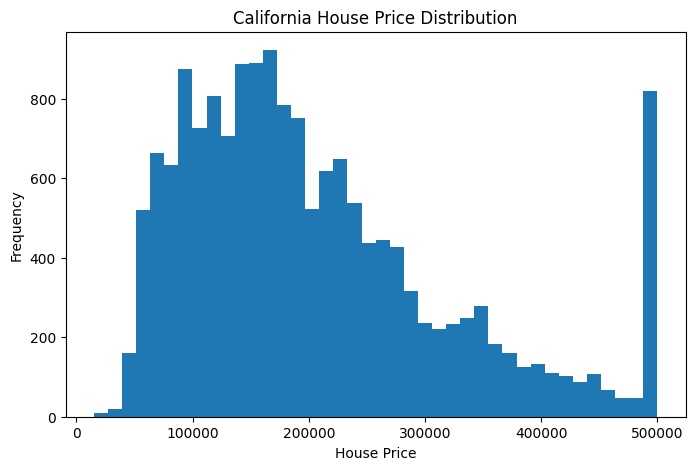

In [ ]:
# Data Visualization
# Histogram of House Prices
plt.figure(figsize=(8,5))

plt.hist(train_labels, bins=40)

plt.title("California House Price Distribution")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

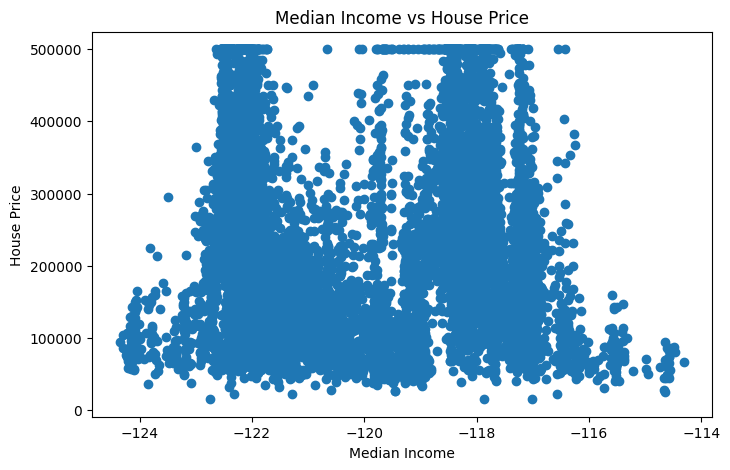

In [ ]:
# Scatter Plot
# Median Income vs House Price
plt.figure(figsize=(8,5))

plt.scatter(train_data[:,0], train_labels)

plt.title("Median Income vs House Price")

plt.xlabel("Median Income")

plt.ylabel("House Price")

plt.show()

In [ ]:
# Normalization
normalizer = tf.keras.layers.Normalization()

normalizer.adapt(train_data)

train_data = normalizer(train_data)

test_data = normalizer(test_data)

In [ ]:
my_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [ ]:
my_model.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

In [ ]:
history = my_model.fit(
    train_data,
    train_labels,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 55815487488.0000 - mae: 206310.8594 - val_loss: 56227520512.0000 - val_mae: 206646.1562
Epoch 2/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54101786624.0000 - mae: 202500.3594 - val_loss: 52815335424.0000 - val_mae: 199056.5156
Epoch 3/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 48609259520.0000 - mae: 189760.2812 - val_loss: 45102972928.0000 - val_mae: 180756.8125
Epoch 4/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 39411044352.0000 - mae: 166201.0781 - val_loss: 34657320960.0000 - val_mae: 153100.5312
Epoch 5/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29071749120.0000 - mae: 136812.8750 - val_loss: 24711964672.0000 - val_mae: 123391.3047


In [ ]:
loss, mae = my_model.evaluate(test_data, test_labels)

print("Test Loss:", loss)
print("Mean Absolute Error:", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24222580736.0000 - mae: 122226.9219
Test Loss: 24222580736.0
Mean Absolute Error: 122226.921875


In [ ]:
prediction = my_model.predict(test_data[:5])

print("Predicted Prices")

print(prediction)

print("\nActual Prices")

print(test_labels[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Prices
[[ 80564.125]
 [ 48061.02 ]
 [ 72385.91 ]
 [124838.61 ]
 [140037.52 ]]

Actual Prices
[397900. 227900. 172100. 186500. 148900.]


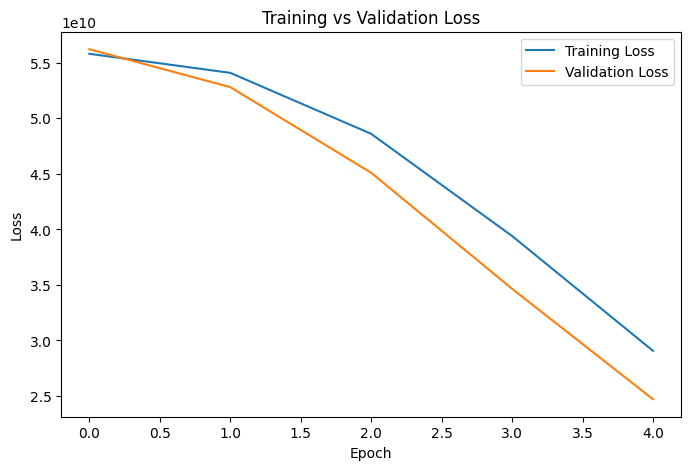

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
my_model.save("california_house_model.keras")

print("Model Saved Successfully")

Model Saved Successfully
